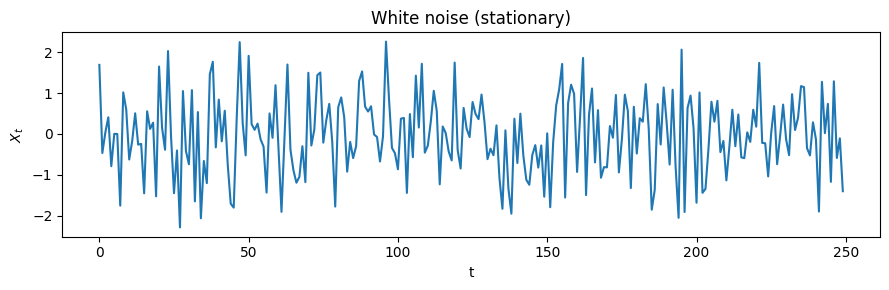

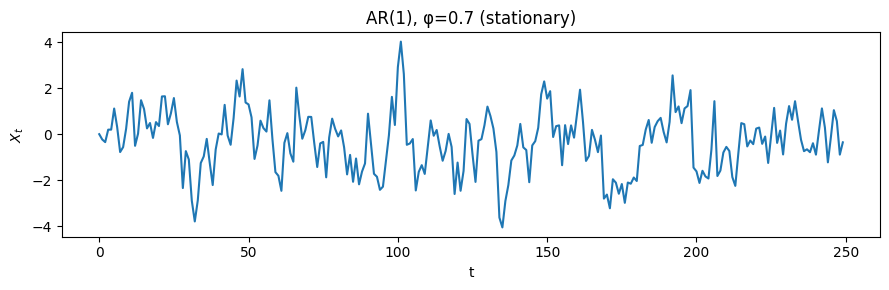

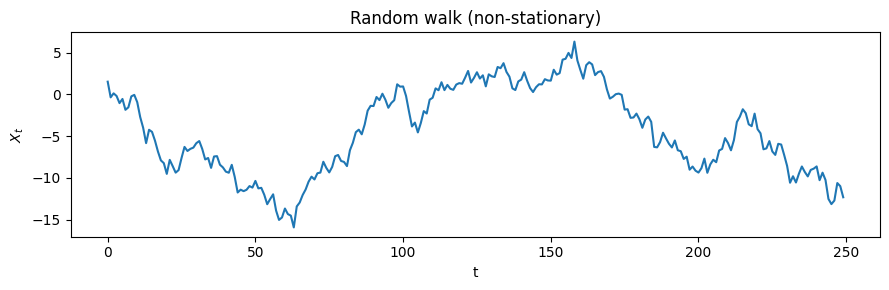

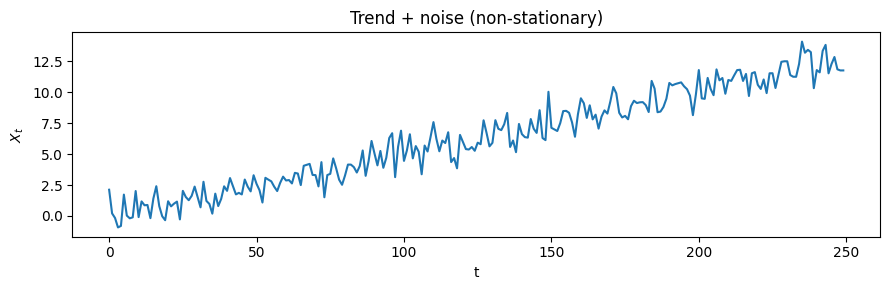

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(7)

n = 250
t = np.arange(n)

# (1) White noise (stationary)
wn = np.random.normal(0, 1, n)

# (2) AR(1) stationary: X_t = phi X_{t-1} + eps_t, |phi|<1
phi = 0.7
eps2 = np.random.normal(0, 1, n)
ar1 = np.zeros(n)
for i in range(1, n):
    ar1[i] = phi * ar1[i - 1] + eps2[i]

# (3) Random walk (non-stationary): X_t = X_{t-1} + eps_t
rw = np.cumsum(np.random.normal(0, 1, n))

# (4) Trend + noise (non-stationary): X_t = 0.05 t + eps_t
trend = 0.05 * t + np.random.normal(0, 1, n)

series = {
    "White noise (stationary)": wn,
    "AR(1), φ=0.7 (stationary)": ar1,
    "Random walk (non-stationary)": rw,
    "Trend + noise (non-stationary)": trend,
}

# Plot each series (one figure per process)
for title, x in series.items():
    plt.figure(figsize=(9, 3))
    plt.plot(t, x)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(r"$X_t$")
    plt.tight_layout()
    plt.show()



# **Augmented Dicker-Fuller (ADF) Test**

$$
\Delta y_t \;=\; y_t - y_{t-1}.
$$

$$
\Delta y_t \;=\; \alpha \;+\; \gamma\,y_{t-1} \;+\; \sum_{i=1}^{p}\delta_i\,\Delta y_{t-i} \;+\; \varepsilon_t.
$$

$$
\Delta y_t \;=\; \alpha \;+\; \beta t \;+\; \gamma\,y_{t-1} \;+\; \sum_{i=1}^{p}\delta_i\,\Delta y_{t-i} \;+\; \varepsilon_t.
$$

$$
H_0:\ \gamma = 0
\qquad \text{vs} \qquad
H_1:\ \gamma < 0.
$$

$$
y_t \;=\; \rho\,y_{t-1} \;+\; \varepsilon_t
\qquad \Longleftrightarrow \qquad
\Delta y_t \;=\; (\rho-1)\,y_{t-1} \;+\; \varepsilon_t.
$$

$$
\gamma \;=\; \rho - 1.
$$


True change points (demo): [220, 440, 660]
Detected boundaries: [155, 270, 365, 695]

Segments (start, end, score):
  [   0,  155)  score=0.000  => stationary-ish
  [ 155,  270)  score=0.934  => non-stationary-ish
  [ 270,  365)  score=0.297  => non-stationary-ish
  [ 365,  695)  score=0.964  => non-stationary-ish
  [ 695,  880)  score=0.000  => stationary-ish


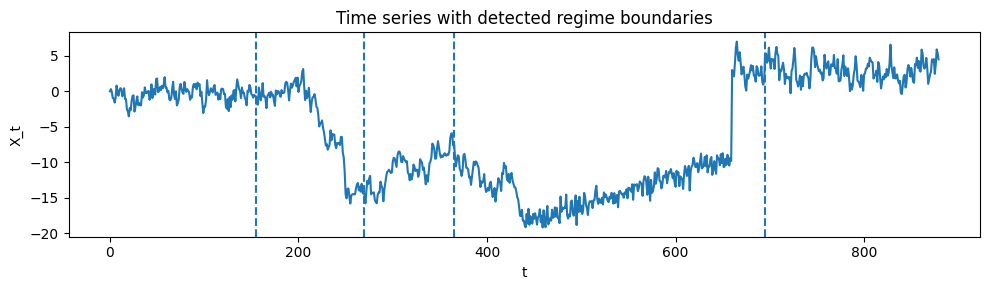

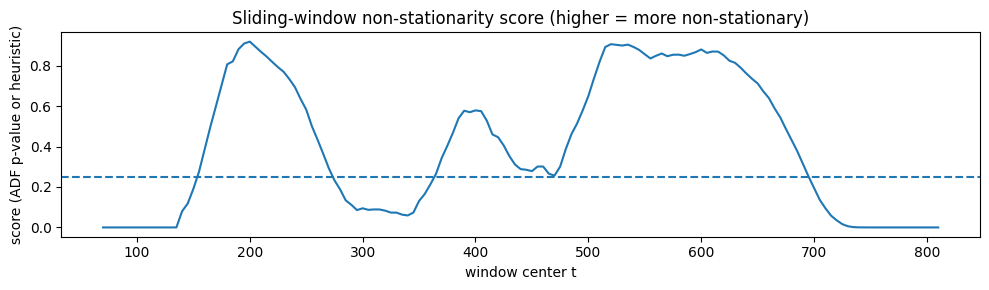

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: use ADF test if statsmodels is installed
try:
    from statsmodels.tsa.stattools import adfuller
except Exception:
    adfuller = None


# -----------------------------
# 1) Simulate a multi-regime series (for demo)
# -----------------------------
def simulate_regime_series(seed=7):
    rng = np.random.default_rng(seed)

    def ar1(n, phi=0.7, sigma=1.0, mean=0.0):
        eps = rng.normal(0, sigma, n)
        x = np.zeros(n)
        for t in range(1, n):
            x[t] = phi * x[t - 1] + eps[t]
        return x + mean

    def random_walk(n, sigma=1.0, start=0.0):
        eps = rng.normal(0, sigma, n)
        return start + np.cumsum(eps)

    def trend_noise(n, slope=0.03, sigma=1.0, start=0.0):
        t = np.arange(n)
        return start + slope * t + rng.normal(0, sigma, n)

    seg1 = ar1(220, phi=0.6, sigma=1.0, mean=0.0)         # stationary
    seg2 = random_walk(220, sigma=1.0, start=seg1[-1])     # non-stationary (unit root-ish)
    seg3 = trend_noise(220, slope=0.04, sigma=1.0, start=seg2[-1])  # non-stationary (trend)
    seg4 = ar1(220, phi=0.5, sigma=1.2, mean=3.0)          # stationary (different mean)

    x = np.concatenate([seg1, seg2, seg3, seg4])
    true_cps = [len(seg1), len(seg1) + len(seg2), len(seg1) + len(seg2) + len(seg3)]
    return x, true_cps


# -----------------------------
# 2) ACF + heuristics (fallback when no ADF)
# -----------------------------
def acf_mean_abs(x, max_lag=10):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom <= 1e-12:
        return 0.0
    vals = []
    for k in range(1, max_lag + 1):
        vals.append(np.dot(x[k:], x[:-k]) / denom)
    return float(np.mean(np.abs(vals)))

def rolling_mean(x, w):
    if w < 2 or w > len(x):
        return np.array([])
    return np.convolve(x, np.ones(w) / w, mode="valid")

def rolling_var(x, w):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if w < 2 or w > n:
        return np.array([])
    c1 = np.cumsum(np.r_[0.0, x])
    c2 = np.cumsum(np.r_[0.0, x * x])
    sum_w = c1[w:] - c1[:-w]
    sum2_w = c2[w:] - c2[:-w]
    m = sum_w / w
    return (sum2_w / w) - m * m

def heuristic_nonstationarity_score(window_x):
    """
    Higher => more non-stationary-looking.
    Based on mean drift, variance drift, trend strength, ACF persistence.
    """
    x = np.asarray(window_x, dtype=float)
    n = len(x)
    eps = 1e-12
    sd = np.std(x) + eps

    # rolling stats within the window
    w = max(10, n // 5)
    rm = rolling_mean(x, w)
    rv = rolling_var(x, w)
    if len(rm) == 0 or len(rv) == 0:
        return np.inf

    mean_drift = np.std(rm) / sd
    var_drift = np.std(rv) / (np.mean(rv) + eps)

    # trend (normalized slope)
    t = np.arange(n, dtype=float)
    t0 = t - t.mean()
    x0 = x - x.mean()
    slope = np.dot(t0, x0) / (np.dot(t0, t0) + eps)
    slope_norm = np.abs(slope) * n / sd

    # ACF persistence
    ac_persist = acf_mean_abs(x, max_lag=min(10, n // 5))

    return float(0.35 * mean_drift + 0.25 * var_drift + 0.25 * ac_persist + 0.15 * slope_norm)

def window_nonstationarity_score(window_x):
    """
    If statsmodels ADF is available:
      use p-value as non-stationarity score (higher p => more non-stationary),
    else use heuristic score.
    """
    x = np.asarray(window_x, dtype=float)
    if adfuller is not None:
        try:
            p = adfuller(x, autolag="AIC")[1]
            return float(p)  # higher p-value => less evidence of stationarity
        except Exception:
            pass
    return heuristic_nonstationarity_score(x)


# -----------------------------
# 3) Sliding-window scoring + regime boundary detection
# -----------------------------
def sliding_scores(x, win=120, step=5):
    x = np.asarray(x, dtype=float)
    n = len(x)
    centers = []
    scores = []
    for start in range(0, n - win + 1, step):
        end = start + win
        s = window_nonstationarity_score(x[start:end])
        centers.append(start + win // 2)
        scores.append(s)
    return np.array(centers), np.array(scores)

def smooth(y, k=7):
    y = np.asarray(y, dtype=float)
    if k <= 1 or k > len(y):
        return y.copy()
    ker = np.ones(k) / k
    return np.convolve(y, ker, mode="same")

def detect_change_points_from_score(centers, scores, thresh, min_region_len=6):
    """
    Simple, robust method:
    - Mark windows where score > thresh as "non-stationary region"
    - Group contiguous marked windows
    - Each region gives two boundaries (start/end), mapped back to time indices.
    """
    mask = scores > thresh
    cps = []

    i = 0
    while i < len(mask):
        if not mask[i]:
            i += 1
            continue
        j = i
        while j < len(mask) and mask[j]:
            j += 1
        # region is [i, j)
        if (j - i) >= min_region_len:
            left = int(centers[i])
            right = int(centers[j - 1])
            cps.extend([left, right])
        i = j

    cps = sorted(set(cps))
    return cps

def classify_segments(x, cps, score_fn, win=160):
    """
    Classify each segment using a mid-window score:
    stationary if score < threshold-ish (ADF p small, or heuristic small).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    boundaries = [0] + [c for c in cps if 0 < c < n] + [n]
    segments = []
    for a, b in zip(boundaries[:-1], boundaries[1:]):
        seg = x[a:b]
        if len(seg) < max(60, win):
            # score directly on segment if small
            s = score_fn(seg)
        else:
            # score on middle window for stability
            mid = (a + b) // 2
            half = win // 2
            lo = max(a, mid - half)
            hi = min(b, mid + half)
            s = score_fn(x[lo:hi])
        segments.append((a, b, s))
    return segments


# -----------------------------
# 4) Demo / run
# -----------------------------
if __name__ == "__main__":
    x, true_cps = simulate_regime_series(seed=7)
    n = len(x)

    # Sliding scores
    win = 140
    step = 5
    centers, raw_scores = sliding_scores(x, win=win, step=step)
    scores = smooth(raw_scores, k=9)

    # Threshold choice:
    # - If ADF available: p-values in [0,1], typical threshold 0.2~0.3 for "likely non-stationary"
    # - If heuristic: scores are unbounded; threshold via percentile works well.
    if adfuller is not None and np.nanmax(scores) <= 1.0:
        thresh = 0.25
    else:
        thresh = float(np.nanpercentile(scores, 70))  # top 30% = "more non-stationary"

    detected_cps = detect_change_points_from_score(
        centers, scores, thresh=thresh, min_region_len=8
    )

    segments = classify_segments(
        x, detected_cps, score_fn=window_nonstationarity_score, win=180
    )

    print("True change points (demo):", true_cps)
    print("Detected boundaries:", detected_cps)
    print("\nSegments (start, end, score):")
    for a, b, s in segments:
        # stationarity label logic depends on scoring type
        if adfuller is not None and s <= 1.0:
            label = "stationary-ish" if s < 0.10 else ("non-stationary-ish" if s > 0.25 else "unclear")
        else:
            label = "stationary-ish" if s < thresh else "non-stationary-ish"
        print(f"  [{a:4d}, {b:4d})  score={s:.3f}  => {label}")

    # Plot 1: series with detected boundaries
    plt.figure(figsize=(10, 3))
    plt.plot(x)
    for cp in detected_cps:
        plt.axvline(cp, linestyle="--")
    plt.title("Time series with detected regime boundaries")
    plt.xlabel("t")
    plt.ylabel("X_t")
    plt.tight_layout()
    plt.show()

    # Plot 2: stationarity/non-stationarity score over time
    plt.figure(figsize=(10, 3))
    plt.plot(centers, scores)
    plt.axhline(thresh, linestyle="--")
    plt.title("Sliding-window non-stationarity score (higher = more non-stationary)")
    plt.xlabel("window center t")
    plt.ylabel("score (ADF p-value or heuristic)")
    plt.tight_layout()
    plt.show()


$$
\mathrm{RM}_t=\frac{1}{w}\sum_{j=0}^{w-1}x_{t+j},\qquad t=0,1,\dots,n-w.
$$
$$
\text{mean_drift}=\frac{\operatorname{Std}(\mathrm{RM})}{\operatorname{Std}(x)+\varepsilon}.
$$

$$
\mathrm{RV}_t=\operatorname{Var}(x_{t:t+w-1}),\qquad t=0,1,\dots,n-w.
$$
$$
\text{var_drift}=\frac{\operatorname{Std}(\mathrm{RV})}{\operatorname{Mean}(\mathrm{RV})+\varepsilon}.
$$

$$
\operatorname{acf}(k)=
\frac{\sum_{t=k}^{n-1}(x_t-\bar x)(x_{t-k}-\bar x)}
{\sum_{t=0}^{n-1}(x_t-\bar x)^2},
\qquad k=1,2,\dots,K.
$$
$$
\text{acf_persist}=\frac{1}{K}\sum_{k=1}^{K}\bigl|\operatorname{acf}(k)\bigr|.
$$

$$
b=\frac{\operatorname{Cov}(t,x)}{\operatorname{Var}(t)},\qquad t=0,1,\dots,n-1.
$$
$$
\text{slope_norm}=\frac{|b|\,n}{\operatorname{Std}(x)+\varepsilon}.
$$

$$
v_1=\operatorname{Var}(x_0,\dots,x_{\lfloor n/2\rfloor-1}),
\qquad
v_2=\operatorname{Var}(x_{\lfloor n/2\rfloor},\dots,x_{n-1}).
$$
$$
\text{var_ratio}=\left|\log\!\left(\frac{v_2}{v_1}\right)\right|.
$$


$$
\text{score}
=0.35\,\text{mean_drift}
+0.25\,\text{var_drift}
+0.25\,\text{acf_persist}
+0.15\,\text{slope_norm}.$$